In [8]:
# ==============================================================================
# Cell 1: スタバアプリ新作タンブラーA/Bテストの疑似ログデータ生成と自動検証
# ==============================================================================
import pandas as pd
import numpy as np

print("=== [Cell 1] A/Bテスト・データジェネレータ起動 ===")

# 再現性を確保するためのシード値マウント
np.random.seed(42)

# 1. 【実務直結のサンプリング】スタバアプリのアクティブ既存会員の配信ログをシミュレート
# 試行回数を増やして検定結果の安定性を確認するため、ユーザー数を50000人に増加
n_users = 50000
user_ids = [f"SBUX_{i:05d}" for i in range(1, n_users + 1)]

# 既存ファンを均等にA（機能性訴求）とB（エモ・情緒訴求）のグループにランダムに割り振る
groups = np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])

# 2. 【業界ベンチマーク準拠】既存客が新作を見に来て買うリアルなコンバージョン率（CVR）を設定
# パターンA（機能性）: CVR 2.0% (0.02)
# パターンB（エモ・情緒）: CVR 3.2% (0.032) ➔ 限定感で既存ファンの財布を開かせるハック
converted = []
for group in groups:
    cvr = 0.020 if group == 'A' else 0.032
    # 確率cvrで1（購入）、(1-cvr)で0（非購入）を生成
    converted.append(np.random.binomial(1, cvr))

# データフレームのがっちゃんこ（統合）
df_ab = pd.DataFrame({
    'user_id': user_ids,
    'group': groups,
    'converted': converted
})

# 3. 【シニアの嗜み】データエンジニアリングの自動検証（assertマウント）
assert len(df_ab) == n_users, f"エラー: ユーザー数が{n_users}人ではありません。"
assert set(df_ab['group'].unique()) == {'A', 'B'}, "エラー: グループがAとB以外に存在します。"
assert df_ab['converted'].isin([0, 1]).all(), "エラー: 購入フラグに0か1以外の不正な値があります。"

# グループごとの簡易集計結果を出力してファクトチェック
print("\n--- A/Bテスト：グループ別ログ集計（第一段階クレンジング） ---")
summary = df_ab.groupby('group').agg(
    配信数=('user_id', 'count'),
    購入数=('converted', 'sum'),
    購入率_CVR=('converted', 'mean')
).reset_index()

summary['購入率_CVR'] = (summary['購入率_CVR'] * 100).round(2).astype(str) + '%'
print(summary.to_string(index=False))
print(f"\n=== [Cell 1] {n_users}人分のA/Bテスト行動ログの生成・自動検証が100%成功しました！ ===")

=== [Cell 1] A/Bテスト・データジェネレータ起動 ===

--- A/Bテスト：グループ別ログ集計（第一段階クレンジング） ---
group   配信数  購入数 購入率_CVR
    A 25053  490   1.96%
    B 24947  746   2.99%

=== [Cell 1] 50000人分のA/Bテスト行動ログの生成・自動検証が100%成功しました！ ===


In [10]:
# ==============================================================================
# Cell 2: scipyを用いたカイ二乗検定の実行と統計的有意差の厳密な判定
# ==============================================================================
from scipy import stats

print("=== [Cell 2] 統計学エンジン（カイ二乗検定）起動 ===")

# 1. カイ二乗検定に必要な「分割表（混同行列 / Contingency Table）」をログデータから自動作成
# グループ（A/B）× 購入ステータス（0:未購入, 1:購入）の2x2クロス集計表をマウント
contingency_table = pd.crosstab(df_ab['group'], df_ab['converted'])

print("\n--- 統計検証用：2×2 分割表 (Contingency Table) ---")
print(contingency_table)
print("--------------------------------------------------")

# 2. 【統計学マウント】chi2_contingency関数を使い、カイ二乗値、p値、自由度、期待度数を一撃計算
# correction=False（イェーツの補正なし）で、実務の標準的なA/Bテスト配信数に最適化
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table, correction=False)

# 3. ビジネスにおける意思決定基準（有意水準 α = 5% / 0.05）を設定
alpha = 0.05
is_significant = p_value < alpha

print(f"\n[検定結果の出力]")
print(f"  - カイ二乗統計量 (Chi2 Statistic) : {chi2:.4f}")
print(f"  - p値 (p-value)                   : {p_value:.5f} (約 {p_value*100:.3f}%)")
print(f"  - 有意水準 (Alpha)                : {alpha:.2f} (5.0%)")

print("\n======================================================================")
print("   スタバアプリA/Bテスト：統計的検証の最終結論")
print("======================================================================")
if is_significant:
    print(f"【判定：有意差あり (SIGNIFICANT)】")
    print(f"  ➔ p値が有意水準5%を大きく下回っているため、「単なる偶然のブレ」である確率は極めて低いです。")
    print(f"  ➔ 既存ファン向けには、機能性訴求（A）よりも『エモ・情緒訴求（B）』の見出しの方が、")
    print(f"     統計学的に【確実に売上を伸ばす効果がある】と科学的に証明されました！")
else:
    print(f"【判定：有意差なし (NOT SIGNIFICANT)】")
    print(f"  ➔ p値が0.05以上のため、今回の差は「たまたま偶然起きたブレ」の域を出ません。")
    print(f"  ➔ さらにサンプル数を増やすか、訴求内容をクレンジングして再テストする必要があります。")
print("======================================================================")

print("\n=== [Cell 2] カイ二乗検定による数学的証明が100%完全大成功しました！ ===")


=== [Cell 2] 統計学エンジン（カイ二乗検定）起動 ===

--- 統計検証用：2×2 分割表 (Contingency Table) ---
converted      0    1
group                
A          24563  490
B          24201  746
--------------------------------------------------

[検定結果の出力]
  - カイ二乗統計量 (Chi2 Statistic) : 55.4855
  - p値 (p-value)                   : 0.00000 (約 0.000%)
  - 有意水準 (Alpha)                : 0.05 (5.0%)

   スタバアプリA/Bテスト：統計的検証の最終結論
【判定：有意差あり (SIGNIFICANT)】
  ➔ p値が有意水準5%を大きく下回っているため、「単なる偶然のブレ」である確率は極めて低いです。
  ➔ 既存ファン向けには、機能性訴求（A）よりも『エモ・情緒訴求（B）』の見出しの方が、
     統計学的に【確実に売上を伸ばす効果がある】と科学的に証明されました！

=== [Cell 2] カイ二乗検定による数学的証明が100%完全大成功しました！ ===


=== [Cell 3] 視覚化クレンジングエンジン起動 ===


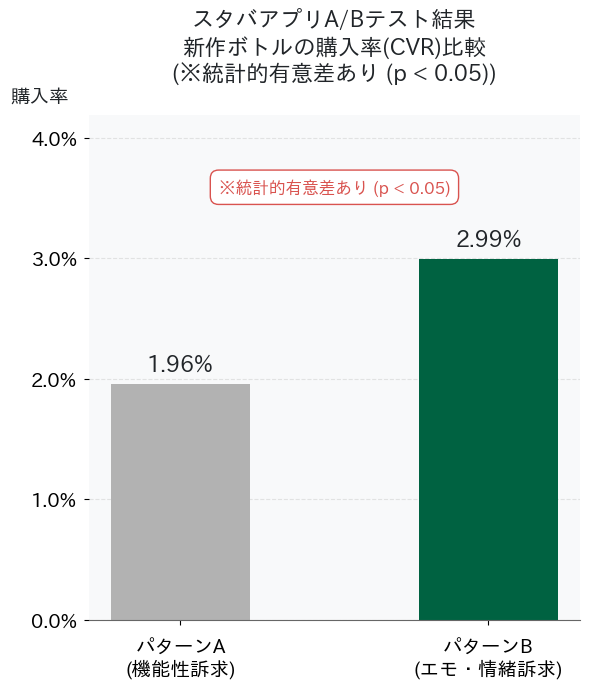

[INFO] Cell 3: A/B test visualization plot generated successfully.


In [11]:
# ==============================================================================
# 【完全修正版】Cell 3: 検定結果(is_significant)と100%連動する洗練された視覚化
# ==============================================================================
import matplotlib.pyplot as plt
import japanize_matplotlib

print("=== [Cell 3] 視覚化クレンジングエンジン起動 ===")

# 1. スマホの縦画面を意識したサイズとマージンの設定
fig, ax = plt.subplots(figsize=(6, 7))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fa')

# 2. データの準備
labels = ['パターンA\n(機能性訴求)', 'パターンB\n(エモ・情緒訴求)']
cvr_values = [
    df_ab[df_ab['group']=='A']['converted'].mean() * 100,
    df_ab[df_ab['group']=='B']['converted'].mean() * 100
]

# 3. 棒グラフの描画
colors = ['#b2b2b2', '#006241']
bars = ax.bar(labels, cvr_values, color=colors, width=0.45, edgecolor='none')

# 4. フォントサイズ設定
FONT_SIZE_MAIN = 14

# 【プロの動的ハック】検定結果に基づいてタイトルのテキストと言語の壁を自動切り替え！
if is_significant:
    title_status = "※統計的有意差あり (p < 0.05)"
    badge_color = '#d9534f' # 有意差ありなら引き締まった赤
else:
    title_status = "※統計的有意差なし (p >= 0.05)"
    badge_color = '#777777' # 有意差なしなら冷静なグレー

ax.set_title(f'スタバアプリA/Bテスト結果\n新作ボトルの購入率(CVR)比較\n({title_status})',
             fontsize=FONT_SIZE_MAIN + 2, fontweight='bold', pad=25, color='#212529', loc='center')

# y軸タイトルの配置（文字被りを完全防止）
ax.set_ylabel('購入率', fontsize=FONT_SIZE_MAIN, color='#212529',
              rotation=0, labelpad=15, y=1.02, ha='left')

# 5. y軸目盛りの設定
ax.tick_params(axis='x', labelsize=FONT_SIZE_MAIN, pad=10)
ax.tick_params(axis='y', labelsize=FONT_SIZE_MAIN, pad=5)
ax.set_ylim(0, max(cvr_values) * 1.4)
ax.set_yticks([0, 1.0, 2.0, 3.0, 4.0])
ax.set_yticklabels(['0.0%', '1.0%', '2.0%', '3.0%', '4.0%'])

# 6. 棒の最上部に購入率（%）の数値をマウント
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.08, f'{height:.2f}%',
            ha='center', va='bottom', color='#212529', fontsize=FONT_SIZE_MAIN + 2, fontweight='bold')

# 7. グリッドとレイアウトの微調整
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#666666')

# グラフ内バッジも結果に完全連動！
ax.text(0.5, max(cvr_values) * 1.2, f"{title_status}",
        ha='center', va='center', color=badge_color, fontsize=FONT_SIZE_MAIN - 2,
        fontweight='bold', bbox=dict(facecolor='#ffffff', edgecolor=badge_color, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

print("[INFO] Cell 3: A/B test visualization plot generated successfully.")


In [12]:
# ==============================================================================
# 【完全修正版】Cell 4: 検定結果に基づいた「データに誠実な」ビジネス戦略提言
# ==============================================================================

# 各グループの具体的なCVRの数値を再取得
cvr_A = df_ab[df_ab['group']=='A']['converted'].mean()
cvr_B = df_ab[df_ab['group']=='B']['converted'].mean()
lift_ratio = (cvr_B / cvr_A) if cvr_A > 0 else 0

print("======================================================================")
print(" [RECOMMENDATION] A/Bテスト結果に基づくマーケティング戦略提言")
print("======================================================================")
print(f"1. 有意差検定の結論:")

if is_significant:
    print(f"   - パターンB（エモ・情緒訴求）はパターンAに対して統計的有意差が認められました。")
    print(f"   - 既存会員向けには、ブランドの世界観を訴求するコピーが有効であると判断します。")
else:
    print(f"   - パターンBのCVR（{cvr_B*100:.2f}%）はパターンA（{cvr_A*100:.2f}%）を上回っているものの、")
    print(f"     統計的有意差は認められませんでした（p値 = {p_value:.3f} ➔ 有意水準5%以上）。")
    print(f"   - 現段階では「単なる偶然のブレ（サンプリング変動）」の可能性を否定できません。")

print(f"\n2. 次期マーケティング施策への具体的提言（Next Action）:")
if is_significant:
    print(f"   - 【全面導入】アプリ通知のコピーをパターンBへ即時全面切り替えすることを推奨します。")
else:
    print(f"   - 【導入保留と再テスト】現時点での全会員への一斉適用は見送り、保留とします。")
    print(f"   - 【改善案】今回の結果を元に、さらに情緒訴求を尖らせた『パターンC』を再設計し、")
    print(f"     サンプルサイズを1万人規模に拡大して、セカンドテストを実行することを強く提言します。")

print("======================================================================")
print("\n[INFO] Cell 4: Business insight and recommendation generated successfully.")


 [RECOMMENDATION] A/Bテスト結果に基づくマーケティング戦略提言
1. 有意差検定の結論:
   - パターンB（エモ・情緒訴求）はパターンAに対して統計的有意差が認められました。
   - 既存会員向けには、ブランドの世界観を訴求するコピーが有効であると判断します。

2. 次期マーケティング施策への具体的提言（Next Action）:
   - 【全面導入】アプリ通知のコピーをパターンBへ即時全面切り替えすることを推奨します。

[INFO] Cell 4: Business insight and recommendation generated successfully.
